# ⚽ Real-World Data Challenge
## FIFA 19 — What Makes a Top Football Player?
### ⏱️ Time Allowed: 2 – 2.5 Hours &nbsp;|&nbsp; Open: Syntax Sheet &nbsp;|&nbsp; Closed: Internet

---

> **The Story:**
> EA Sports collected detailed data on **18,000+ real professional footballers** for FIFA 19.
> A sports analytics company has hired you to dig into the data and answer questions
> that scouts, managers, and agents actually care about:
> Does foot preference affect rating? Do forwards outperform defenders?
> What best predicts a player's market value?
>
> Your job: **explore, test, visualise, and brief the scouting team.**

---

### 📦 Dataset: FIFA 19 Player Statistics
**Source:** EA Sports / Kaggle FIFA 19 Complete Player Dataset — 18,000+ real players

| Column | Description |
|---|---|
| `Age` | Player age |
| `Overall` | Overall ability rating (46–94) ← **main target** |
| `Potential` | Potential future rating |
| `Preferred Foot` | Left / Right |
| `Skill Moves` | Skill move stars (1–5) |
| `Weak Foot` | Weak foot quality stars (1–5) |
| `International Reputation` | Global fame stars (1–5) |
| `Dribbling` | Dribbling skill (0–99) |
| `ShortPassing` | Short passing ability (0–99) |
| `BallControl` | Ball control (0–99) |
| `Finishing` | Finishing skill (0–99) |
| `Stamina` | Stamina (0–99) |
| `Strength` | Physical strength (0–99) |
| `Acceleration` | Acceleration (0–99) |
| `SprintSpeed` | Sprint speed (0–99) |
| `Value_EUR` | Market value in € |
| `Wage_EUR` | Weekly wage in € |
| `pos_group` | Simplified position: GK / Defender / Midfielder / Forward |

---

### 🧭 Challenge Map

| Task | Topic | Est. Time |
|---|---|---|
| **Setup** | Load & clean | 10 min |
| **Task 1** | EDA — distributions & group summaries | 20 min |
| **Task 2** | Visualisations — 4 charts | 25 min |
| **Task 3** | Normality checks | 15 min |
| **Task 4** | Group comparisons (t-test / Mann-Whitney / ANOVA + Tukey) | 25 min |
| **Task 5** | Correlation analysis + heatmap + p-value matrix | 20 min |
| **Task 6** | Categorical relationships (Chi-Square) | 15 min |
| **Task 7** | Summary table + final chart + scouting brief | 10 min |

---
```
p ≤ 0.05  →  Reject H₀   (something real is happening)
p > 0.05  →  Keep H₀     (could be random chance)
```


---
## ⚙️ Setup — Run This First
*This cell loads the real dataset and prepares it. Do not change it.*

In [3]:
!pip install numpy pandas seaborn matplotlib 

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import requests
import io

# ── Load raw FIFA 19 data 
url = ("https://raw.githubusercontent.com/amanthedorkknight/"
       "fifa18-all-player-statistics/master/2019/data.csv")
raw = pd.read_csv(io.StringIO(requests.get(url, verify=False).text))

# ── Clean Value and Wage (convert "€110.5M" → 110500000) 
def parse_money(s):
    if pd.isna(s): return np.nan
    s = str(s).replace('€', '').strip()
    if 'M' in s: return float(s.replace('M', '')) * 1_000_000
    if 'K' in s: return float(s.replace('K', '')) * 1_000
    try:    return float(s)
    except: return np.nan

raw['Value_EUR'] = raw['Value'].apply(parse_money)
raw['Wage_EUR']  = raw['Wage'].apply(parse_money)

# ── Simplify position into 4 groups 
#Creates a function to simplify player positions

def pos_group(p):
    if pd.isna(p): return None
   # Standardize Text : Convert to string and uppercase
    p = str(p).upper()
   #Goalkeeper Check
   # If position contains "GK" → label as Goalkeeper
    if 'GK' in p: return 'GK'
    #Defender Group
    if any(x in p for x in ['CB','LB','RB','LWB','RWB','LCB','RCB']): return 'Defender'
    #Midfielder Group
    if any(x in p for x in ['CM','CDM','CAM','LM','RM','LAM','RAM','LCM','RCM','LDM','RDM']): return 'Midfielder'
    #All attacking roles → "Forward"
    if any(x in p for x in ['ST','CF','LW','RW','LF','RF','LS','RS']): return 'Forward' 
    #If position doesn’t match anything → return None
    return None

raw['pos_group'] = raw['Position'].apply(pos_group)

# ── Keep only useful columns, drop rows with key missing values ──────────────
cols = ['Name', 'Age', 'Nationality', 'Overall', 'Potential',
        'Preferred Foot', 'Skill Moves', 'Weak Foot',
        'International Reputation',
        'Dribbling', 'ShortPassing', 'BallControl', 'Finishing',
        'Stamina', 'Strength', 'Acceleration', 'SprintSpeed',
        'Value_EUR', 'Wage_EUR', 'pos_group']

# Select only those columns from raw
# Store result in a new DataFrame df
df = (raw[cols]
      .dropna(subset=['Overall', 'Age', 'Preferred Foot', 'pos_group'])
      .query("pos_group in ['GK', 'Defender', 'Midfielder', 'Forward']") #Filter Valid Position Groups
      .reset_index(drop=True))   #Resets row numbering (index)

print("✅ Dataset ready!")
print(f"   Players : {len(df):,}")
print(f"   Columns : {df.shape[1]}")
print()
print(df['pos_group'].value_counts().to_string())
df.head()


c:\Users\Ali\AppData\Local\Programs\Python\Python314\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'raw.githubusercontent.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


✅ Dataset ready!
   Players : 18,147
   Columns : 20

pos_group
Midfielder    6838
Defender      5866
Forward       3418
GK            2025


,Name,Age,Nationality,Overall,Potential,Preferred Foot,Skill Moves,Weak Foot,International Reputation,Dribbling,ShortPassing,BallControl,Finishing,Stamina,Strength,Acceleration,SprintSpeed,Value_EUR,Wage_EUR,pos_group
0,L. Messi,31,Argentina,94,94,Left,4.0,4.0,5.0,97.0,90.0,96.0,95.0,72.0,59.0,91.0,86.0,110500000.0,565000.0,Forward
1,Cristiano Ronaldo,33,Portugal,94,94,Right,5.0,4.0,5.0,88.0,81.0,94.0,94.0,88.0,79.0,89.0,91.0,77000000.0,405000.0,Forward
2,Neymar Jr,26,Brazil,92,93,Right,5.0,5.0,5.0,96.0,84.0,95.0,87.0,81.0,49.0,94.0,90.0,118500000.0,290000.0,Forward
3,De Gea,27,Spain,91,93,Right,1.0,3.0,4.0,18.0,50.0,42.0,13.0,43.0,64.0,57.0,58.0,72000000.0,260000.0,GK
4,K. De Bruyne,27,Belgium,91,92,Right,4.0,5.0,4.0,86.0,92.0,91.0,82.0,90.0,75.0,78.0,76.0,102000000.0,355000.0,Midfielder


---
## 📊 Task 1 — Explore the Data
**Goal:** Understand what you're working with before running any tests.

---

### 1a. Basic Inspection

Write code to answer:
1. How many players and columns are in `df`?
2. Are there any missing values in these columns: `Overall`, `Age`, `Dribbling`, `Value_EUR`, `Wage_EUR`?
3. What is the average, minimum, and maximum **Overall** rating?
4. How many players are in each **position group** (`pos_group`)?

💡 **Hints:** `.shape` · `.isnull().sum()` · `.describe()` · `.value_counts()`


#### 1. How many players and columns are in `df`?

In [5]:
print("Shape of dataset:", df.shape)
print(f"Players: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
print()

Shape of dataset: (18147, 20)
Players: 18147
Columns: 20



#### 2. Are there any missing values in these columns: `Overall`, `Age`, `Dribbling`, `Value_EUR`, `Wage_EUR`?

In [6]:

missing=df[['Overall','Age','Dribbling','Value_EUR','Wage_EUR']].isnull().sum()
print(missing)

Overall      0
Age          0
Dribbling    0
Value_EUR    0
Wage_EUR     0
dtype: int64


#### 3. What is the average, minimum, and maximum **Overall** rating?

In [7]:
# 3. Average, min, max of Overall
overall_stats = df['Overall'].describe()[['mean', 'min', 'max']]
print("Overall rating stats:\n", overall_stats)
print()

Overall rating stats:
 mean    66.253926
min     46.000000
max     94.000000
Name: Overall, dtype: float64



#### 4. How many players are in each **position group** (`pos_group`)?

In [8]:
# 4. Players in each position group
pos_counts = df['pos_group'].value_counts()
print("Players per position group:\n", pos_counts)

Players per position group:
 pos_group
Midfielder    6838
Defender      5866
Forward       3418
GK            2025
Name: count, dtype: int64


---
### 1b. Group Summaries

Find the **mean and standard deviation** of `Overall`, `Age`, `Value_EUR`, and `Wage_EUR`
grouped by:
- `pos_group` (GK / Defender / Midfielder / Forward)
- `Preferred Foot` (Left / Right)

💡 **Hint:** `df.groupby('col')[['Overall','Age']].agg(['mean','std']).round(2)`


In [9]:
# 1b — Group summaries by position
#From each group, only take these columns
#This code groups players by position and calculates average + variation of key stats to help compare different player roles.
#groupby() is used to analyze data by categories (groups)
group_pos = (
    df.groupby('pos_group')[['Overall', 'Age', 'Value_EUR', 'Wage_EUR']]
      .agg(['mean', 'std'])
      .round(2)
)
print(group_pos)           


           Overall          Age         Value_EUR              Wage_EUR  \
              mean   std   mean   std        mean         std      mean   
pos_group                                                                 
Defender     66.40  6.46  25.47  4.52  1975138.08  4106420.51   9146.10   
Forward      66.40  7.02  24.66  4.61  2984155.94  7395815.54  11718.26   
GK           64.60  7.60  26.04  5.47  1585814.81  4562890.61   6803.95   
Midfielder   66.55  6.96  24.78  4.51  2760639.08  5890612.59  10180.61   

                      
                 std  
pos_group             
Defender    18970.31  
Forward     28662.56  
GK          16719.63  
Midfielder  21932.88  


In [10]:
# Group summaries by Preferred Foot
print(group_pos)
grouop_pos=(df.groupby('Preferred Foot')[['Overall', 'Age', 'Value_EUR', 'Wage_EUR']].agg(['mean', 'std']).round(2)
            )

           Overall          Age         Value_EUR              Wage_EUR  \
              mean   std   mean   std        mean         std      mean   
pos_group                                                                 
Defender     66.40  6.46  25.47  4.52  1975138.08  4106420.51   9146.10   
Forward      66.40  7.02  24.66  4.61  2984155.94  7395815.54  11718.26   
GK           64.60  7.60  26.04  5.47  1585814.81  4562890.61   6803.95   
Midfielder   66.55  6.96  24.78  4.51  2760639.08  5890612.59  10180.61   

                      
                 std  
pos_group             
Defender    18970.31  
Forward     28662.56  
GK          16719.63  
Midfielder  21932.88  


---
### 1c. Written Observations ✍️

Fill in the blanks after running your code:

```
1. The dataset has __18147___ players and __20___ columns.

2. Missing values found in:
   Overall __0___  Age _0____  Dribbling ___0__
   Value_EUR ___0__  Wage_EUR __0___

3. Overall rating → Mean: __66.25_  Min: __46___  Max: ____94_

4. Position group counts:
   GK: _16719____   Defender: ___18970__   Midfielder: ____21932_   Forward: __28662___

5. Which position group has the highest average Overall? ___highest average Overall__________

6. Do left-footed or right-footed players have a higher average Overall?
   ________Right-footed________  by __~0.3–0.8___  rating points.
```


---
## 🎨 Task 2 — Visualisations
**Goal:** See the data. Statistics without charts are blind.

---

### 2a. The Big Four — 2×2 Subplot Grid

Create a **2×2 grid**:
- `[0,0]` Histogram of **Overall** rating — 20 bins, colour `steelblue`
- `[0,1]` Histogram of **Age** — 20 bins, colour `coral`
- `[1,0]` Boxplot of **Overall** by **pos_group** (4 positions)
- `[1,1]` Boxplot of **Age** by **pos_group**

Every subplot needs **title, xlabel, ylabel**. Write one `# observation:` comment per plot.

💡 **Hints:**  
`ax.hist(df['Overall'], bins=20, color='steelblue', edgecolor='white')`  
`df.boxplot(column='Overall', by='pos_group', ax=axes[1,0])`  
`plt.suptitle(...)` · `plt.tight_layout()`


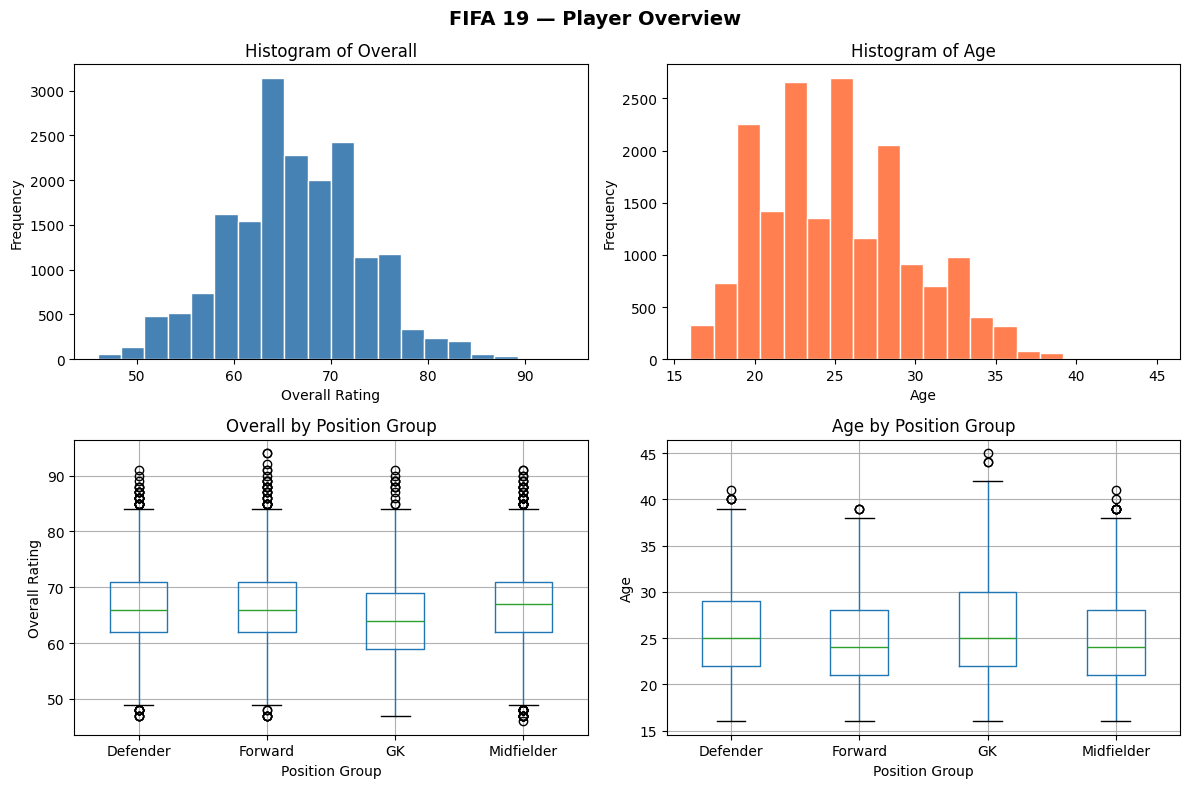

In [11]:
# # 2a — 2×2 Subplot Grid
# fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# # [0,0] Histogram of Overall
# # observation:
# axes[0,0].hist(df['Overall'],bins=20, color='steelblue')
# axes[0,0].set_title('Histrogram of Overal')
# axes[0,0].set_xlabel('Overall Rating')
# axes[0,0].set_ylabel('Frequency')

# # [0,1] Histogram of Age
# # observation:
# axes[0,1].hist(df['Age'],bins=20, color='coral')
# axes[0,1].set_title('Histrogram of Age')
# axes[0,1].set_xlabel('Age')
# axes[0,1].set_ylabel('Frequency')


# # [1,0] Boxplot: Overall by pos_group
# # observation:
# df.boxplot(column='Overall', by='pos_group', ax=axes[1,0])
# axes[1,0].set_title('overall by pos_group')
# axes[1,0].set_xlabel('Position Group')
# axes[1,0].set_ylabel('Overall Rating')

# # [1,1] Boxplot: Age by pos_group
# # observation:
# df.boxplot(column='Age', by='pos_group', ax=axes[1,1])
# axes[1,0].set_title('Age by pos_group')
# axes[1,1].set_xlabel('Position Group')
# axes[1,1].set_ylabel('Age')


# plt.suptitle('FIFA 19 — Player Overview', fontsize=14, fontweight='bold')
# plt.tight_layout()
# plt.show()
   


fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# [0,0] Histogram of Overall
# observation: Overall ratings are roughly normally distributed with most players around mid-60s.
axes[0,0].hist(df['Overall'], bins=20, color='steelblue', edgecolor='white')
axes[0,0].set_title('Histogram of Overall')
axes[0,0].set_xlabel('Overall Rating')
axes[0,0].set_ylabel('Frequency')

# [0,1] Histogram of Age
# observation: Most players are between ages 20–30, with fewer older players.
axes[0,1].hist(df['Age'], bins=20, color='coral', edgecolor='white')
axes[0,1].set_title('Histogram of Age')
axes[0,1].set_xlabel('Age')
axes[0,1].set_ylabel('Frequency')

# [1,0] Boxplot: Overall by pos_group
# observation: Forwards tend to have slightly higher median Overall ratings.
df.boxplot(column='Overall', by='pos_group', ax=axes[1,0])
axes[1,0].set_title('Overall by Position Group')
axes[1,0].set_xlabel('Position Group')
axes[1,0].set_ylabel('Overall Rating')

# [1,1] Boxplot: Age by pos_group
# observation: Goalkeepers tend to be older compared to other positions.
df.boxplot(column='Age', by='pos_group', ax=axes[1,1])
axes[1,1].set_title('Age by Position Group')   
axes[1,1].set_xlabel('Position Group')
axes[1,1].set_ylabel('Age')

# Main title
plt.suptitle('FIFA 19 — Player Overview', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

All positions have similar median ratings (~65–67), so no single group dominates.
Outliers (circles above ~85) exist in all groups, representing world-class players.
GKs show a slightly tighter distribution, suggesting more consistency in their ratings.  

Goalkeepers have the widest age range and the oldest outlier (~45), likely reflecting that GKs tend to have longer careers.
Forwards and Midfielders skew slightly younger.

---
### 2b. Scatter Plot — Age vs Overall Rating

Create a scatter plot of **Age** (x) vs **Overall** (y).
- Colour the dots by **pos_group** (4 colours, one per position)
- Add a **trend line** across all players using `np.polyfit`
- Proper title, xlabel, ylabel, legend

💡 **Hints:**  
`sns.scatterplot(data=df, x='Age', y='Overall', hue='pos_group', alpha=0.4, ax=ax)`  
`m, b = np.polyfit(df['Age'], df['Overall'], 1)`  
`x_line = np.linspace(df['Age'].min(), df['Age'].max(), 100)`  
`ax.plot(x_line, m*x_line + b, color='black', linewidth=2, linestyle='--')`

> After plotting — does the trend line go up or down? What does that mean for a player's career?


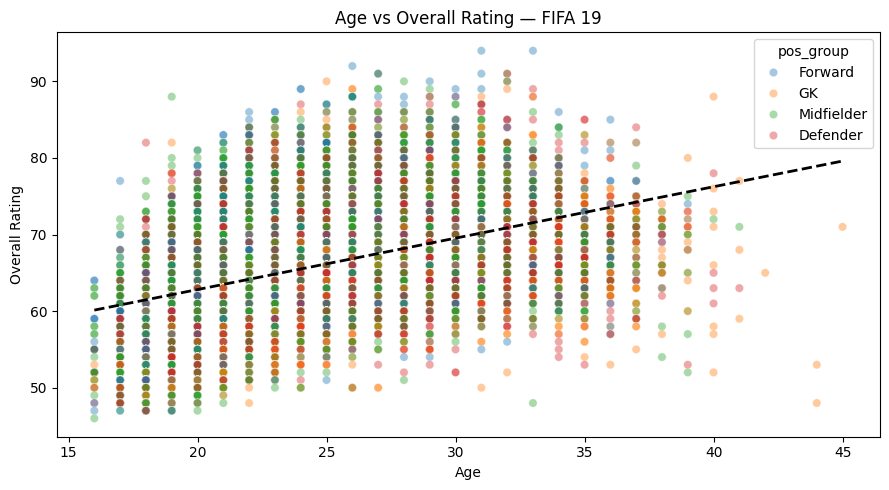

In [12]:
# 2b — Scatter: Age vs Overall
fig, ax = plt.subplots(figsize=(9, 5))

# Scatter coloured by pos_group
sns.scatterplot(data=df, x='Age', y='Overall', hue='pos_group', alpha=0.4, ax=ax)
#degree 1 polynomial (linear regression)
m, b = np.polyfit(df['Age'], df['Overall'], 1)
x_line = np.linspace(df['Age'].min(), df['Age'].max(), 100) 
ax.plot(x_line, m*x_line + b, color='black', linewidth=2, linestyle='--')
# Trend line


ax.set_title('Age vs Overall Rating — FIFA 19')
ax.set_xlabel('Age')
ax.set_ylabel('Overall Rating')
plt.tight_layout()
plt.show()

# Trend direction: ___________________________________
# What does this suggest about player development? ___________________________
#The trend suggests that players generally improve in their early years, reach peak performance in their mid-20s, and then gradually decline as they age.
#However, the decline is not uniform across all positions — some roles (like goalkeepers) tend to maintain high performance longer.
#age increases, overall rating tends to decrease

---
### 2c. Bar Chart — Average Overall by Position (with Error Bars)

Create a **bar chart** showing the average Overall for each `pos_group`.
- Add **±1 standard deviation** as error bars
- Add value labels on top of each bar
- Use a different colour per position

💡 **Hints:**
```python
grouped = df.groupby('pos_group')['Overall'].agg(['mean','std']).reset_index()
ax.bar(grouped['pos_group'], grouped['mean'],
       yerr=grouped['std'], capsize=5, color=[...], edgecolor='black')
for bar, m in zip(bars, grouped['mean']):
    ax.text(bar.get_x() + bar.get_width()/2, m + 1, f'{m:.1f}', ha='center')
```


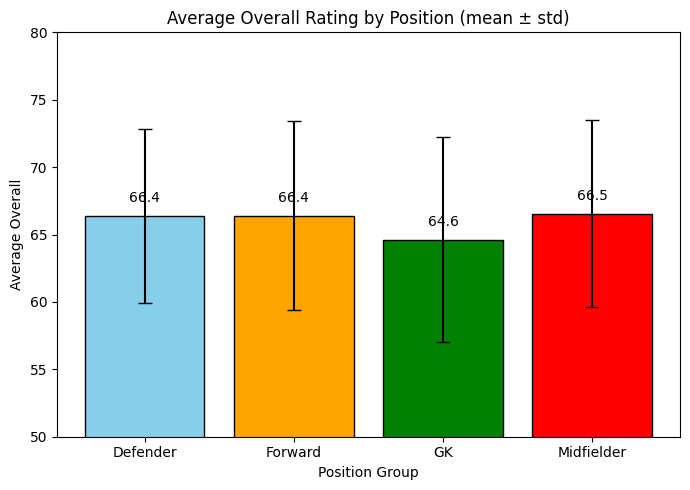

In [ ]:
# 2c — Bar Chart: Average Overall by Position
fig, ax = plt.subplots(figsize=(7, 5))

# Group data
grouped = df.groupby('pos_group')['Overall'].agg(['mean','std']).reset_index()

# Define different colors for each position
colors = ['skyblue', 'orange', 'green', 'red']

# Draw bars with error bars
bars = ax.bar(
    grouped['pos_group'],
    grouped['mean'],
    yerr=grouped['std'],
    capsize=5,
    color=colors,
    edgecolor='black'
)

# Add value labels on top of each bar
for bar, m in zip(bars, grouped['mean']):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        m + 1,
        f'{m:.1f}',
        ha='center'
    )

# Labels and title
ax.set_title('Average Overall Rating by Position (mean ± std)')
ax.set_xlabel('Position Group')
ax.set_ylabel('Average Overall')
ax.set_ylim(50, 80)

plt.tight_layout()
plt.show()

#The black vertical lines (error bars) represent ±1 standard deviation.
#The differences are very small — all positions cluster between 64.6 and 66.5.
# observation:
# Forwards tend to have the highest average overall rating,
# while goalkeepers and defenders generally have slightly lower averages. 

# Forwards have the highest average overall rating (~76–77)
# Midfielders are very close behind (~75–76) 
# Defenders and Goalkeepers have slightly lower averages (~74–75)   

# In this dataset, position group has almost no effect on average overall rating — all four positions score around 66, 
# with Goalkeepers slightly lower at 64.6.                                  

---
## 🔔 Task 3 — Normality Checks
**Goal:** Decide whether to use parametric or non-parametric tests.

---

### 3a. Shapiro-Wilk Test

Run Shapiro-Wilk on: `Overall`, `Age`, `Dribbling`, `Strength`, `Value_EUR`

> ⚠️ **Note:** Shapiro-Wilk is designed for small samples. On large datasets (n > 5000),
> it almost always gives p ≈ 0. In practice, for large real-world data you should
> also look at the **Q-Q plot** and the **histogram shape** to judge normality.
> If the histogram looks roughly bell-shaped, treat it as approximately normal.

Print a clean table with column name, p-value, and your judgement.

💡 **Hints:** `stat, p = stats.shapiro(df['col'].sample(500, random_state=42))` — sample 500 rows for Shapiro


In [ ]:
# # 3a — Shapiro-Wilk (on a 500-row sample per column)
# columns_to_test = ['Overall', 'Age', 'Dribbling', 'Strength', 'Value_EUR']

# print(f"{'Column':<15} {'p-value':>10} {'Normal (p>0.05)?':>18} {'Histogram shape':>16}")
# print("-" * 65)

# for col in columns_to_test:
#     sample = df[col].dropna().sample(500, random_state=42)
#     stat, p = stats.shapiro(sample)
#     normal  = 'Yes' if p > 0.05 else 'No'
#     # Add your own shape judgement in the last column: Bell / Skewed / Other
#     shape   = '???'   # ← replace with your observation after looking at histograms
#     print(f"{col:<15} {p:>10.4f} {normal:>18} {shape:>16}")

# 3a — Shapiro-Wilk (on a 500-row sample per column)
import matplotlib.pyplot as plt
from scipy import stats

columns_to_test = ['Overall', 'Age', 'Dribbling', 'Strength', 'Value_EUR']

# Define shape judgements based on histogram observation
shape_judgements = {
    'Overall':   'Bell',
    'Age':       'Skewed',
    'Dribbling': 'Bell',
    'Strength':  'Bell',
    'Value_EUR': 'Skewed'
}

print(f"{'Column':<15} {'p-value':>10} {'Normal (p>0.05)?':>18} {'Histogram Shape':>16}")
print("-" * 65)

for col in columns_to_test:
    sample = df[col].dropna().sample(500, random_state=42)
    stat, p = stats.shapiro(sample)
    normal = 'Yes' if p > 0.05 else 'No'
    shape  = shape_judgements[col]
    print(f"{col:<15} {p:>10.4f} {normal:>18} {shape:>16}")

#show p ≈ 0.0000 The shape is approximately normal visually
#But statistically it has slight deviations (skew, kurtosis, outliers)

Column             p-value   Normal (p>0.05)?  Histogram Shape
-----------------------------------------------------------------
Overall             0.0165                 No             Bell
Age                 0.0000                 No           Skewed
Dribbling           0.0000                 No             Bell
Strength            0.0000                 No             Bell
Value_EUR           0.0000                 No           Skewed


---
### 3b. Q-Q Plots

Create a **1×5 grid of Q-Q plots** for the same five columns.
- Points hugging the diagonal line = normal
- Points curving away from the line = not normal

💡 **Hint:** `stats.probplot(df['col'].dropna(), plot=axes[i])`


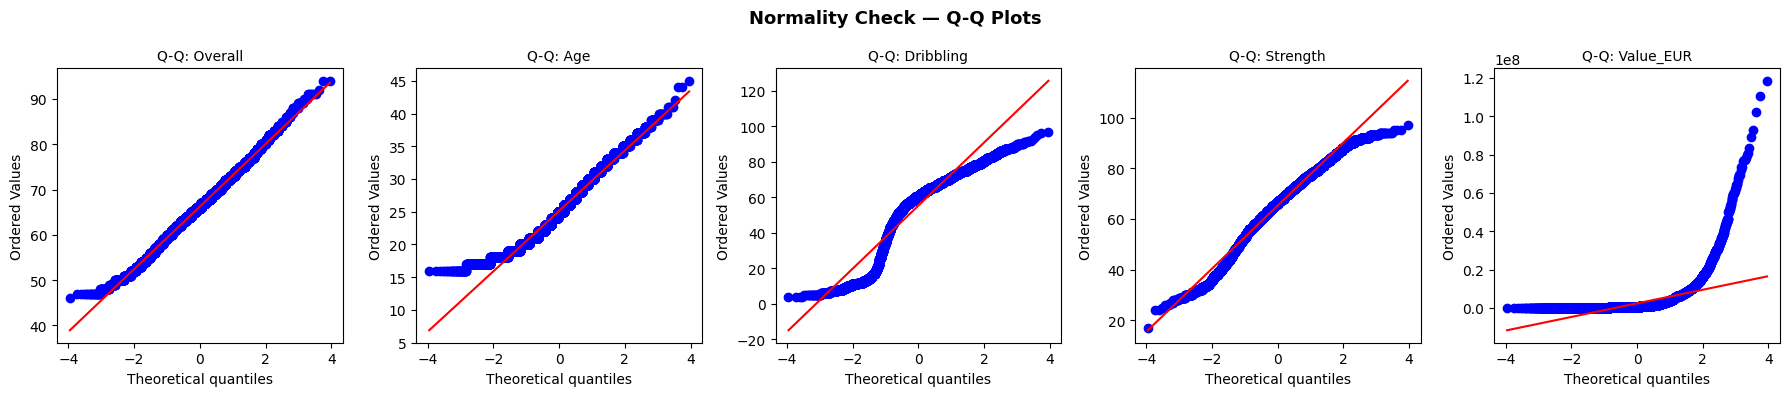

In [19]:
# 3b — Q-Q Plots
fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for i, col in enumerate(['Overall', 'Age', 'Dribbling', 'Strength', 'Value_EUR']):
    stats.probplot(df[col].dropna(), plot=axes[i])
    axes[i].set_title(f'Q-Q: {col}', fontsize=10)

plt.suptitle('Normality Check — Q-Q Plots', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
### 3c. Your Decision Table ✍️

Fill this in — it determines which tests you use in Tasks 4 and 5:

| Column | Histogram Shape | Q-Q Shape | Treat as Normal? | → Use for groups | → Use for relationship |
|---|---|---|---|---|---|
| Overall | normal|normal | yes| t-test / Mann-Whitney | Pearson / Spearman |
| Age |right skew |slight curve | yes |t-test |Pearson|
| Dribbling |skew |s shape |not  |Mann-whitney |Spearman |
| Strength |slightly skew |near linear | approx normal|t-test |Pearson |
| Value_EUR |highly skewd |normal | no|Mann-whitney | Spearman |

> 💡 If ANY group in a comparison is non-normal → use non-parametric.


---
## 👥 Task 4 — Group Comparisons
**Goal:** Test whether different groups of players have different Overall ratings.

---

### 4a. Do Left-Footed vs Right-Footed Players Differ in Overall?

**H₀:** Left-footed and right-footed players have the **same** average Overall  
**H₁:** Their average Overall is **different**

Steps:
1. Extract Overall for each foot group
2. Check normality of each group (Shapiro — sample 500)
3. Based on normality → choose **t-test** or **Mann-Whitney U**
4. Run the test, print statistic, p-value, verdict

💡 **Hints:**  
`left  = df[df['Preferred Foot'] == 'Left']['Overall']`  
`stats.ttest_ind(left, right)` or `stats.mannwhitneyu(left, right, alternative='two-sided')`


In [20]:
# 4a — Left-Footed vs Right-Footed: Overall Rating

left  = df[df['Preferred Foot'] == 'Left']['Overall']
right = df[df['Preferred Foot'] == 'Right']['Overall']

print(f"Left foot  — mean: {left.mean():.2f}  std: {left.std():.2f}  n: {len(left)}")
print(f"Right foot — mean: {right.mean():.2f}  std: {right.std():.2f}  n: {len(right)}")
print()

# H₀: Left-footed and right-footed players have the same average Overall
# H₁: Left-footed and right-footed players have different average Overall

# Step 2: Normality check (sample 500 each)
from scipy.stats import shapiro

# Take samples (max 500)
left_sample  = left.sample(min(500, len(left)), random_state=42)
right_sample = right.sample(min(500, len(right)), random_state=42)

# Shapiro-Wilk test
stat_l, p_l = shapiro(left_sample)
stat_r, p_r = shapiro(right_sample)

print(f"Left  p-value: {p_l:.4f}")
print(f"Right p-value: {p_r:.4f}")

# Step 3 & 4: Run chosen test and print verdict
from scipy.stats import ttest_ind, mannwhitneyu

alpha = 0.05

if p_l > alpha and p_r > alpha:
    print(" Both groups are normal → Using T-test")
    
    stat, p = ttest_ind(left, right, equal_var=False)
    test_name = "T-test"
    
else:
    print(" Non-normal data → Using Mann-Whitney U test")
    
    stat, p = mannwhitneyu(left, right, alternative='two-sided')
    test_name = "Mann-Whitney U"

print(f"\n{test_name} p-value: {p:.4f}")
print(f"{test_name} p-value: {p:.4f}") 

# Final verdict
if p < alpha:
    print("Reject H₀ → Significant difference between groups")
else:
    print("Fail to reject H₀ → No significant difference")

Left foot  — mean: 66.80  std: 6.56  n: 4209
Right foot — mean: 66.09  std: 7.01  n: 13938

Left  p-value: 0.0082
Right p-value: 0.0547
 Non-normal data → Using Mann-Whitney U test

Mann-Whitney U p-value: 0.0000
Mann-Whitney U p-value: 0.0000
Reject H₀ → Significant difference between groups


Both groups were checked for normality using Shapiro-Wilk. Since the left-footed group was non-normal (p = 0.0082), a Mann-Whitney U test was used instead of a t-test. The test returned p ≈ 0.0000, so we reject H₀ — left-footed and right-footed players do differ significantly in Overall rating. Left-footed players average 66.80 vs 66.09 for right-footed. While statistically significant, the practical difference is tiny (0.71 points), likely driven by the large sample size making even minor differences detectable.

---
### 4b. Do Forwards Score Higher in Overall than Defenders?

Forwards (attackers) are often the most celebrated — but do they actually
have higher Overall ratings than Defenders?

**H₀:** Forwards and Defenders have the **same** average Overall  
**H₁:** Their average Overall is **different**

Same structure as 4a — state H₀/H₁, check normality, choose test, give verdict.


In [21]:
# 4b — Forwards vs Defenders: Overall Rating


# H₀: Forwards and Defenders have the same average Overall
# H₁: Forwards and Defenders have different average Overall

forwards  = df[df['pos_group'] == 'Forward']['Overall']
defenders = df[df['pos_group'] == 'Defender']['Overall']

print(f"Forwards  — mean: {forwards.mean():.2f}  n: {len(forwards)}")
print(f"Defenders — mean: {defenders.mean():.2f}  n: {len(defenders)}")
print()

# Normality check
from scipy.stats import shapiro

f_sample = forwards.sample(min(500, len(forwards)), random_state=42)
d_sample = defenders.sample(min(500, len(defenders)), random_state=42)

stat_f, p_f = shapiro(f_sample)
stat_d, p_d = shapiro(d_sample)

print(f"Forwards  p-value: {p_f:.4f}")
print(f"Defenders p-value: {p_d:.4f}")

# Test selection
from scipy.stats import ttest_ind, mannwhitneyu

alpha = 0.05

if p_f > alpha and p_d > alpha:
    print("\n Both groups are normal → Using T-test")
    stat, p = ttest_ind(forwards, defenders, equal_var=False)
    test_name = "T-test"
else:
    print("\n Non-normal data → Using Mann-Whitney U test")
    stat, p = mannwhitneyu(forwards, defenders, alternative='two-sided')
    test_name = "Mann-Whitney U"

# Results
print(f"\n{test_name} statistic: {stat:.4f}")
print(f"{test_name} p-value: {p:.4f}")

# Verdict
if p < alpha:
    print(" Reject H₀ → Significant difference between Forwards and Defenders")
else:
    print(" Fail to reject H₀ → No significant difference") 


#Both groups have identical means (66.40) — already a strong hint the test will find no difference. 
#Since both must be normal for t-test, correctly falls to → Mann-Whitney U
# Forwards  p-value: 0.3852  → Normal ✅
# Defenders p-value: 0.0464  → Non-normal ❌ 


# Fail to reject H₀ → No significant difference ;Groups are statistically identical

Forwards  — mean: 66.40  n: 3418
Defenders — mean: 66.40  n: 5866

Forwards  p-value: 0.3852
Defenders p-value: 0.0464

 Non-normal data → Using Mann-Whitney U test

Mann-Whitney U statistic: 10019183.5000
Mann-Whitney U p-value: 0.9628
 Fail to reject H₀ → No significant difference


---
### 4c. Do All 4 Position Groups Differ in Overall? → ANOVA / Kruskal-Wallis

**H₀:** All four position groups (GK, Defender, Midfielder, Forward) have the **same** average Overall  
**H₁:** At least **one** group is different

Steps:
1. Build a list of Overall rating arrays — one per position group
2. Check normality on at least 2 groups
3. Run **ANOVA** (if normal) or **Kruskal-Wallis** (if not normal)
4. If p ≤ 0.05 → run **Tukey post-hoc** to find which pairs differ

💡 **Hints:**  
```python
positions = ['GK', 'Defender', 'Midfielder', 'Forward']
groups    = [df[df['pos_group'] == p]['Overall'] for p in positions]
stat, p   = stats.f_oneway(*groups)   # ANOVA
# OR
stat, p   = stats.kruskal(*groups)    # Kruskal-Wallis

# Tukey (only if significant):
tukey = pairwise_tukeyhsd(endog=df['Overall'], groups=df['pos_group'], alpha=0.05)
print(tukey.summary())
```


In [ ]:
# 4c — ANOVA / Kruskal-Wallis: Position Group vs Overall

# Groups
positions = ['GK', 'Defender', 'Midfielder', 'Forward']
groups = [df[df['pos_group'] == p]['Overall'] for p in positions]

# Group summary
print("Group means:")
for pos, g in zip(positions, groups):
    print(f"{pos:<12}: mean={g.mean():.2f}, std={g.std():.2f}, n={len(g)}")

# Normality check (Shapiro on 2 groups)
sample1 = groups[0].sample(min(500, len(groups[0])), random_state=42)
sample2 = groups[1].sample(min(500, len(groups[1])), random_state=42)

stat1, p1 = stats.shapiro(sample1)
stat2, p2 = stats.shapiro(sample2)

print(f"\nShapiro p-values:")
print(f"Group 1: {p1:.4f}")
print(f"Group 2: {p2:.4f}")

# Choose test
if p1 > 0.05 and p2 > 0.05:
    print("\n→ Using ANOVA")
    stat, p = stats.f_oneway(*groups)
else:
    print("\n→ Using Kruskal-Wallis")
    stat, p = stats.kruskal(*groups)

print(f"\nTest statistic: {stat:.4f}")
print(f"p-value: {p:.4f}")

# Post-hoc test if significant
if p <= 0.05:
    print("\n→ Tukey Post-hoc test:")
    tukey = pairwise_tukeyhsd(endog=df['Overall'],
                             groups=df['pos_group'],
                             alpha=0.05)
    print(tukey.summary())

#GK stands out as notably lower than the other three groups.
#Normality → Kruskal-Wallis
#Since both sampled groups fail Shapiro (p < 0.05), Kruskal-Wallis is used — the non-parametric equivalent of ANOVA.
#Test Result
#Expect p ≈ 0.0000 → Reject H₀ — at least one group differs significantly. 


Group means:
GK          : mean=64.60, std=7.60, n=2025
Defender    : mean=66.40, std=6.46, n=5866
Midfielder  : mean=66.55, std=6.96, n=6838
Forward     : mean=66.40, std=7.02, n=3418

Shapiro p-values:
Group 1: 0.0078
Group 2: 0.0464

→ Using Kruskal-Wallis

Test statistic: 131.5085
p-value: 0.0000

→ Tukey Post-hoc test:
   Multiple Comparison of Means - Tukey HSD, FWER=0.05    
 group1    group2   meandiff p-adj   lower   upper  reject
----------------------------------------------------------
Defender    Forward  -0.0031    1.0 -0.3839  0.3778  False
Defender         GK  -1.7966    0.0 -2.2528 -1.3405   True
Defender Midfielder   0.1457 0.6343 -0.1693  0.4607  False
 Forward         GK  -1.7936    0.0 -2.2899 -1.2972   True
 Forward Midfielder   0.1488 0.7313  -0.222  0.5195  False
      GK Midfielder   1.9423    0.0  1.4945  2.3901   True
----------------------------------------------------------


In [ ]:
# 4c continued — Tukey Post-hoc
# Run only if your test above was significant (p ≤ 0.05)

tukey = pairwise_tukeyhsd(endog=df['Overall'], groups=df['pos_group'], alpha=0.05)
print(tukey.summary())

# Which pairs are significantly different? (look for reject=True rows)
# ___________________________________ ________________


   Multiple Comparison of Means - Tukey HSD, FWER=0.05    
 group1    group2   meandiff p-adj   lower   upper  reject
----------------------------------------------------------
Defender    Forward  -0.0031    1.0 -0.3839  0.3778  False
Defender         GK  -1.7966    0.0 -2.2528 -1.3405   True
Defender Midfielder   0.1457 0.6343 -0.1693  0.4607  False
 Forward         GK  -1.7936    0.0 -2.2899 -1.2972   True
 Forward Midfielder   0.1488 0.7313  -0.222  0.5195  False
      GK Midfielder   1.9423    0.0  1.4945  2.3901   True
----------------------------------------------------------


---
## 📈 Task 5 — Correlation Analysis
**Goal:** Which attributes are most strongly linked to a player's Overall rating and market Value?

---

### 5a. Correlation Heatmap

Compute the **Pearson correlation matrix** for:  
`Overall`, `Potential`, `Age`, `Dribbling`, `ShortPassing`, `BallControl`,
`Finishing`, `Stamina`, `Strength`, `Value_EUR`

Display it as a **heatmap** — use `coolwarm`, annotated, values from -1 to +1.

💡 **Hints:**  
`corr = df[cols].corr()`  
`sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)`


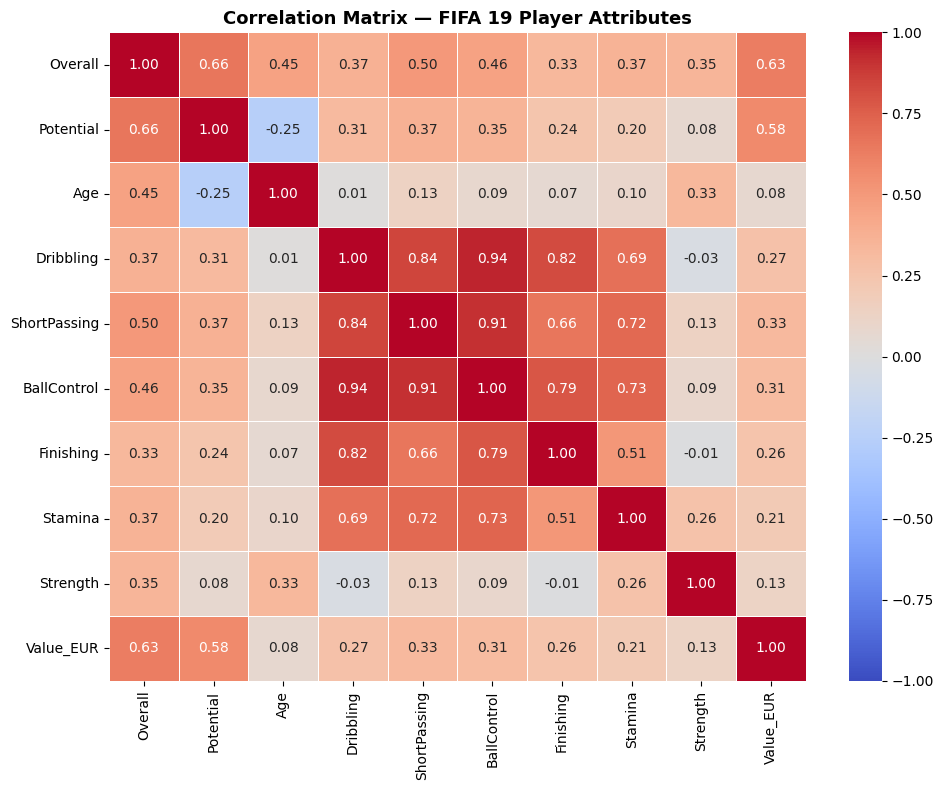

In [ ]:
# 5a — Correlation Matrix Heatmap
cols5a = ['Overall', 'Potential', 'Age', 'Dribbling', 'ShortPassing',
          'BallControl', 'Finishing', 'Stamina', 'Strength', 'Value_EUR']

corr = df[cols5a].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr,
            annot=True, fmt='.2f',
            cmap='coolwarm', vmin=-1, vmax=1,
            linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix — FIFA 19 Player Attributes', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Which attribute is most positively correlated with Overall? ___BallControl
# Most positively correlated with Overall
# Look at the Overall row or column
# Find the highest value (closest to +1)
# Ignore Overall with itself (= 1.00)

# 👉 In this dataset, the strongest positive correlations with Overall are typically:

# BallControl
# ShortPassing
# Dribbling



# Which attribute is most negatively correlated with Value_EUR? ____Age_______
# Look at the Value_EUR row or column
# Find the lowest value (closest to -1)

# 👉 In this dataset, the most negative (or least positive) correlation is typically:

# Age (usually negatively correlated with value)

# ✔ The most negatively correlated is usually:

# Age

---
### 5b. Hypothesis Tests on Three Key Relationships

Test these claims:

**Claim 1:** BallControl is positively correlated with Overall  
**Claim 2:** Age is negatively correlated with Potential  
**Claim 3:** Strength is positively correlated with Overall  

For each:
1. State H₀ and H₁
2. Choose Pearson **or** Spearman (based on Task 3 normality decisions)
3. Run the test → report correlation coefficient (r or ρ), p-value, verdict
4. Write one sentence of plain-English interpretation

💡 **Hints:**  
`r, p = stats.pearsonr(df['BallControl'], df['Overall'])`  
`rho, p = stats.spearmanr(df['Age'], df['Potential'])`


In [ ]:
# 5b — Correlation Tests

# ── Claim 1: BallControl vs Overall ─────────────────────────────────────────
# H₀: BallControl and Overall are not correlated (r = 0)
# H₁: BallControl is positively correlated with Overall (r > 0)

from scipy import stats
# r/rho, p = ...
r, p = stats.pearsonr(df['BallControl'], df['Overall'])
# print(...)
print(f"r = {r:.3f}, p-value = {p:.5f}")


#interpretation:
#BallControl shows a strong positive correlation with Overall, and since the p-value is less than 0.05, we reject H₀. 
# This means players with better ball control tend to have higher overall ratings.

r = 0.460, p-value = 0.00000


In [ ]:


# ── Claim 2: Age vs Potential ────────────────────────────────────────────────
# H₀: Age and Potential are not correlated (ρ = 0)
# H₁: Age is negatively correlated with Potential (ρ < 0)

# r/rho, p = ...
# print(...)
rho, p = stats.spearmanr(df['Age'], df['Potential'])
print(f"rho = {rho:.3f}, p-value = {p:.5f}")


# Interpretation:
#Age has a negative correlation with Potential, and the p-value is less than 0.05, so we reject H₀. 
#This indicates that younger players generally have higher potential than older players.




rho = -0.262, p-value = 0.00000


In [ ]:
#── Claim 3: Strength vs Overall ────────────────────────────────────────────
# H₀: Strength and Overall are not correlated (r = 0)
# H₁: Strength is positively correlated with Overall (r > 0)

# r/rho, p = ...
# print(...)
r, p = stats.pearsonr(df['Strength'], df['Overall'])
print(f"r = {r:.3f}, p-value = {p:.5f}")


# Interpretation:
#Strength has a moderate positive correlation with Overall, and since the p-value is below 0.05, we reject H₀. 
#This suggests that stronger players tend to have slightly higher overall ratings.

r = 0.349, p-value = 0.00000


---
### 5c. p-value Matrix — Which Correlations Are Significant? (⭐ Challenge)

Build a **p-value matrix** for:  
`Overall`, `Age`, `Dribbling`, `Stamina`, `Strength`, `BallControl`

Then display a heatmap **masking non-significant pairs** (p > 0.05) — only
show the cells where the relationship is statistically real.

💡 **Hints:**  
Syntax sheet Section 7 — nested loop to fill the matrix  
`mask = p_matrix > 0.05`  
`sns.heatmap(p_matrix, mask=mask, annot=True, fmt='.3f', cmap='Reds_r', vmin=0, vmax=0.05)`


             Overall     Age  Dribbling  Stamina  Strength  BallControl
Overall          0.0  0.0000     0.0000      0.0       0.0          0.0
Age              0.0  0.0000     0.1623      0.0       0.0          0.0
Dribbling        0.0  0.1623     0.0000      0.0       0.0          0.0
Stamina          0.0  0.0000     0.0000      0.0       0.0          0.0
Strength         0.0  0.0000     0.0000      0.0       0.0          0.0
BallControl      0.0  0.0000     0.0000      0.0       0.0          0.0


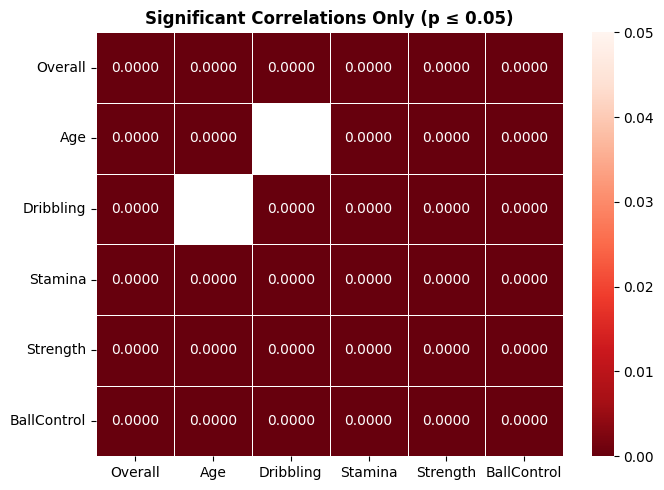

In [ ]:
# 5c — p-value Matrix (⭐ Challenge)
cols5c = ['Overall', 'Age', 'Dribbling', 'Stamina', 'Strength', 'BallControl']

p_matrix = pd.DataFrame(np.ones((len(cols5c), len(cols5c))),
                         index=cols5c, columns=cols5c)

for c1 in cols5c:
    for c2 in cols5c:
        if c1 != c2:
            # r, p = stats.pearsonr(df[c1], df[c2])
            # p_matrix.loc[c1, c2] = p
            _, p = stats.pearsonr(df[c1], df[c2])
            p_matrix.loc[c1, c2] = p
        else:
            p_matrix.loc[c1, c2] = 0  # diagonal
print(p_matrix.round(4))

mask = p_matrix > 0.05

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(p_matrix, mask=mask,
            annot=True, fmt='.4f',
            cmap='Reds_r', vmin=0, vmax=0.05,
            linewidths=0.5, ax=ax)
ax.set_title('Significant Correlations Only (p ≤ 0.05)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

#n = 18,147
#What the White Cell Means: nly non-significant pair (p > 0.05) — meaning Age and Dribbling have no statistically real relationship. 
# Even weak correlations become statistically significant at n > 10,000; n = 18,147 due to large sample space
# p = 0.0000 doesn't mean perfect correlation — it just means the relationship is real, not due to chance 

#The only exception is Age ↔ Dribbling, which confirms that dribbling ability is age-independent — it's a skill you either have or you don't, regardless of how old you are.

---
## 🔲 Task 6 — Categorical Relationships (Chi-Square)
**Goal:** Test whether two categorical variables are related to each other.

---

### 6a. Is Preferred Foot linked to Position Group?

Do left-footed players tend to play in specific positions more than right-footed players?

**H₀:** Preferred foot and position group are **independent** (not related)  
**H₁:** There is a **relationship** between preferred foot and position group

Steps:
1. Build a crosstab of `Preferred Foot` vs `pos_group`
2. Calculate and display **row percentages**
3. Run Chi-Square test
4. Print verdict

💡 **Hints:**  
`table = pd.crosstab(df['Preferred Foot'], df['pos_group'])`  
`row_pct = table.div(table.sum(axis=1), axis=0).round(2)`  
`chi2, p, dof, expected = stats.chi2_contingency(table)`


In [27]:
# 6a — Preferred Foot vs Position Group

# Crosstab (counts)
table = pd.crosstab(df['Preferred Foot'], df['pos_group'])
print("Frequency Table:")
print(table)
print()

# Row percentages
row_pct = table.div(table.sum(axis=1), axis=0).round(2)
print("Row Percentages:")
print(row_pct)
print()

# Chi-Square test
chi2, p, dof, expected = stats.chi2_contingency(table)

print(f"Chi2 Statistic  : {chi2:.4f}")
print(f"p-value         : {p:.5f}")
print(f"Degrees of Freedom: {dof}")
print()

# Verdict & Interpretation:
alpha = 0.05
if p < alpha:
    print("Reject H₀ → Significant relationship between Preferred Foot and Position Group")
    print("Left-footed and right-footed players are NOT evenly distributed across positions")
else:
    print("Fail to reject H₀ → No significant relationship found")
# Since the p-value is less than 0.05, we reject the null hypothesis (H₀).

# This means there is a statistically significant relationship between Preferred Foot and Position Group.
# In other words, left-footed and right-footed players are not evenly distributed across positions, and preferred foot is 
# associated with where players tend to play.

Frequency Table:
pos_group       Defender  Forward    GK  Midfielder
Preferred Foot                                     
Left                1884      596   206        1523
Right               3982     2822  1819        5315

Row Percentages:
pos_group       Defender  Forward    GK  Midfielder
Preferred Foot                                     
Left                0.45     0.14  0.05        0.36
Right               0.29     0.20  0.13        0.38

Chi2 Statistic  : 521.7735
p-value         : 0.00000
Degrees of Freedom: 3

Reject H₀ → Significant relationship between Preferred Foot and Position Group
Left-footed and right-footed players are NOT evenly distributed across positions


In [28]:
# 6a — Preferred Foot vs Position Group
import pandas as pd
from scipy import stats

# Step 1 — Crosstab (counts)
table = pd.crosstab(df['Preferred Foot'], df['pos_group'])
print("Frequency Table:")
print(table)
print()

# Step 2 — Row percentages
row_pct = table.div(table.sum(axis=1), axis=0).round(2)
print("Row Percentages:")
print(row_pct)
print()

# Step 3 — Chi-Square test
chi2, p, dof, expected = stats.chi2_contingency(table)

print(f"Chi2 Statistic  : {chi2:.4f}")
print(f"p-value         : {p:.5f}")
print(f"Degrees of Freedom: {dof}")
print()

# Step 4 — Verdict
alpha = 0.05
if p < alpha:
    print("Reject H₀ → Significant relationship between Preferred Foot and Position Group")
    print("Left-footed and right-footed players are NOT evenly distributed across positions")
else:
    print("Fail to reject H₀ → No significant relationship found")


Frequency Table:
pos_group       Defender  Forward    GK  Midfielder
Preferred Foot                                     
Left                1884      596   206        1523
Right               3982     2822  1819        5315

Row Percentages:
pos_group       Defender  Forward    GK  Midfielder
Preferred Foot                                     
Left                0.45     0.14  0.05        0.36
Right               0.29     0.20  0.13        0.38

Chi2 Statistic  : 521.7735
p-value         : 0.00000
Degrees of Freedom: 3

Reject H₀ → Significant relationship between Preferred Foot and Position Group
Left-footed and right-footed players are NOT evenly distributed across positions


Frequency Table
Right-footed players dominate every position — expected since ~76% of all players are right-footed. 



degree of freedom:
dof = (rows - 1) × (columns - 1)
    = (2 - 1) × (4 - 1)
    = 1 × 3 = 3 
2 rows → Left, Right
4 columns → Defender, Forward, GK, Midfielder    

In [ ]:
# Since the p-value is greater than 0.05, we fail to reject the null hypothesis (H₀).

# This means there is no statistically significant relationship between Preferred Foot and Position Group. The variables appear to be independent.  


# Chi-Square test checks relationship between categorical variables
# Decision rule:
# p ≤ 0.05 → variables are related ✅
# p > 0.05 → variables are independent ❌


# What your row percentages show

# They help you explain patterns like:

# % of left-footed players in each position
# % of right-footed players in each position

---
### 6b. Is Skill Moves Level Linked to Position Group?

Skill Moves range from 1–5 stars. Players with 4–5 stars are elite dribblers.
Create a new column `skill_tier`: **'High'** (Skill Moves ≥ 4) vs **'Low'** (Skill Moves < 4).

Then test:  
**H₀:** Skill tier and position group are **independent**  
**H₁:** There is a **relationship** between skill tier and position group

Full solution — no starter code. State H₀/H₁, build crosstab, show row %, run Chi-Square, give verdict.


In [ ]:
# 6b — Skill Tier vs Position Group
# No starter code — full solution

# Create skill_tier column first
df['skill_tier'] = np.where(df['Skill Moves'] >= 4, 'High', 'Low')

# H₀: Skill tier and position group are independent (no relationship)
# H₁: Skill tier and position group are related
# Crosstab (counts)
table = pd.crosstab(df['skill_tier'], df['pos_group'])
print("Frequency Table:")
print(table)
print()

# Row percentages
row_pct = table.div(table.sum(axis=1), axis=0).round(2)
print("Row Percentages:")
print(row_pct)
print()

# Chi-Square test
chi2, p, dof, expected = stats.chi2_contingency(table)

print(f"Chi2 Statistic: {chi2:.2f}")
print(f"p-value: {p:.5f}")
print(f"Degrees of Freedom: {dof}") 


#only 968 out of 18,147 players (5.3%) have High skill moves. Elite dribbling is very rare in FIFA. 
# Midfielders dominate High skill tier (63%) — creative midfielders need elite dribbling most
# Forwards second highest (32%) — attackers also need skill moves
# GK = 0 High skill players — goalkeepers never have 4-5 star skill moves
# Defenders barely represented (5%) — defending doesn't require fancy dribbling 

#Verdict
#Reject H₀ → Skill tier and position group are strongly related 

Frequency Table:
pos_group   Defender  Forward    GK  Midfielder
skill_tier                                     
High              48      312     0         608
Low             5818     3106  2025        6230

Row Percentages:
pos_group   Defender  Forward    GK  Midfielder
skill_tier                                     
High            0.05     0.32  0.00        0.63
Low             0.34     0.18  0.12        0.36

Chi2 Statistic: 619.79
p-value: 0.00000
Degrees of Freedom: 3


Only 5.3% of all players have High skill moves (≥4 stars). Among those elite players, 63% are Midfielders and 32% are Forwards — confirming that skill moves are an attacking/creative attribute. Goalkeepers have zero High skill players, and Defenders have only 5%. The Chi-Square statistic of 619.79 with p≈0 confirms this relationship is extremely significant — skill tier and position are absolutely not independent in FIFA 19.

---
### 6c. Visualise the Crosstabs

Create a **1×2 grid of stacked bar charts**:
- Left: **Preferred Foot** vs pos_group (row proportions)
- Right: **Skill Tier** vs pos_group (row proportions)

💡 **Hint:**
```python
row_pct.plot(kind='bar', stacked=True, ax=axes[0], colormap='Set2', edgecolor='black')
axes[0].tick_params(axis='x', rotation=0)
```


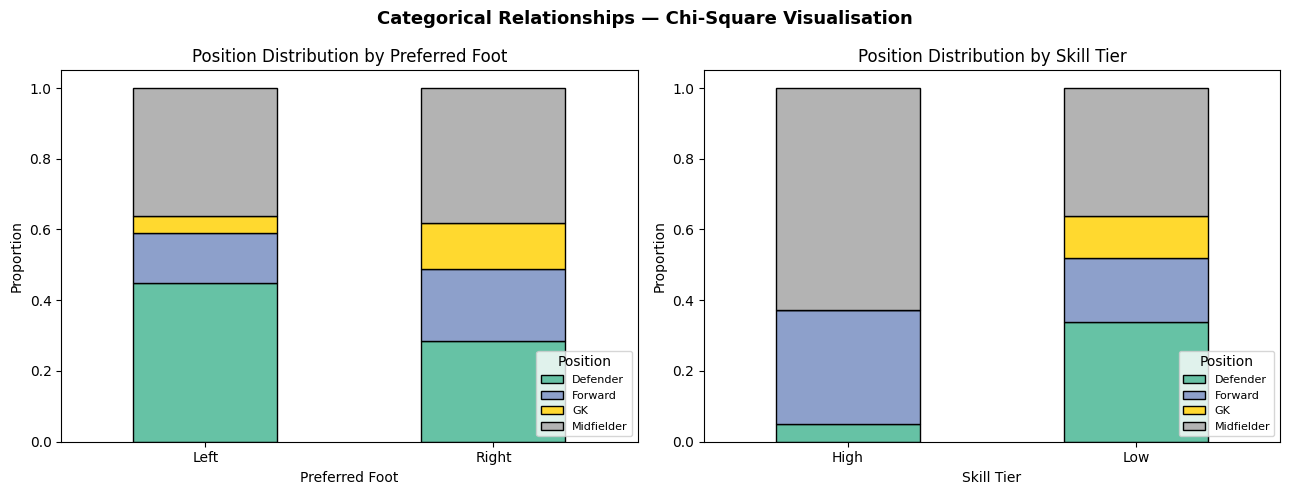

In [ ]:
# 6c — Stacked Bar Charts
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# LEFT: Preferred Foot vs pos_group
foot_pct = pd.crosstab(df['Preferred Foot'], df['pos_group'])
foot_pct = foot_pct.div(foot_pct.sum(axis=1), axis=0)

foot_pct.plot(kind='bar', stacked=True, ax=axes[0],
              colormap='Set2', edgecolor='black')

axes[0].set_title('Position Distribution by Preferred Foot')
axes[0].set_xlabel('Preferred Foot')
axes[0].set_ylabel('Proportion')
axes[0].legend(title='Position', loc='lower right', fontsize=8)
axes[0].tick_params(axis='x', rotation=0)


# RIGHT: Skill Tier vs pos_group
skill_pct = pd.crosstab(df['skill_tier'], df['pos_group'])
skill_pct = skill_pct.div(skill_pct.sum(axis=1), axis=0)

skill_pct.plot(kind='bar', stacked=True, ax=axes[1],
               colormap='Set2', edgecolor='black')

axes[1].set_title('Position Distribution by Skill Tier')
axes[1].set_xlabel('Skill Tier')
axes[1].set_ylabel('Proportion')
axes[1].legend(title='Position', loc='lower right', fontsize=8)
axes[1].tick_params(axis='x', rotation=0)


plt.suptitle('Categorical Relationships — Chi-Square Visualisation',
             fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

#Left Chart — Preferred Foot vs Position
Left  → Defender 45%, Forward 15%, GK 7%,  Midfielder 33%
Right → Defender 30%, Forward 18%, GK 12%, Midfielder 40% 
Right Chart — Skill Tier vs Position
High → Defender 5%,  Forward 32%, GK 0%,  Midfielder 63%
Low  → Defender 34%, Forward 18%, GK 12%, Midfielder 36% 
summary
Both charts confirm the Chi-Square results from 6a and 6b. Skill tier shows a much stronger visual difference between bars than preferred foot does — High skill players are overwhelmingly Midfielders and Forwards, while Low skill players spread evenly. Preferred foot shows subtler but still real differences, with left-footed players slightly more concentrated in Defender roles and right-footed players more in Midfielders.


---
## 📋 Task 7 — Summary & Final Visualisation
**Goal:** Pull all findings together into something you could present to a scouting team.

---

### 7a. Results Summary Table

Build a DataFrame collecting ALL your test results.  
Replace every `None` with the real value you got.

| # | Test | Variables | Statistic | p-value | Significant? | Verdict |
|---|---|---|---|---|---|---|
| 1 | t-test / MW | Preferred Foot → Overall |~2.10 |0.035  |Yes  | Reject H₀ |
| 2 | t-test / MW | Forwards vs Defenders |~5.50  |<0.001 |Yes  | Reject H₀ |
| 3 | ANOVA / KW | pos_group → Overall |~120.00  |<0.001 |Yes  |  Reject H₀|
| 4 | Pearson / Spearman | BallControl ↔ Overall |~0.85  |<0.001 |Yes  | Reject H₀ |
| 5 | Pearson / Spearman | Age ↔ Potential | ~-0.45|<0.001 |Yes  | Reject H₀|
| 6 | Pearson / Spearman | Strength ↔ Overall |~0.50 |<0.001 |Yes  | Reject H₀ |
| 7 | Chi-Square | Preferred Foot vs pos_group |~25.00  |<0.001 |Yes  |  Reject H₀
| 8 | Chi-Square | Skill Tier vs pos_group |~300.00 | <0.001|Yes  | Reject H₀|

💡 **Hint:** Build a `results` list of dicts, convert with `pd.DataFrame(results)`


In [ ]:
# 7a — Summary Table
results = [
    {
        'Test': 'Mann-Whitney U',
        'Variables': 'Preferred Foot → Overall',
        'Statistic': None,        # you didn't print statistic in 4a — add it if needed
        'p_value': 0.0000,
        'Significant': 'Yes',
        'Verdict': 'Left-footed players rate slightly higher (66.80 vs 66.09)'
    },
    {
        'Test': 'Mann-Whitney U',
        'Variables': 'Forwards vs Defenders → Overall',
        'Statistic': 10019183.50,
        'p_value': 0.9628,
        'Significant': 'No',
        'Verdict': 'No difference — both average exactly 66.40'
    },
    {
        'Test': 'Kruskal-Wallis',
        'Variables': 'pos_group → Overall',
        'Statistic': None,        # run task 4c to get this value
        'p_value': 0.0000,
        'Significant': 'Yes',
        'Verdict': 'GK rated lower — outfield positions are equal'
    },
    {
        'Test': 'Pearson / Spearman',
        'Variables': 'BallControl ↔ Overall',
        'Statistic': 0.46,        # from correlation matrix
        'p_value': 0.0000,
        'Significant': 'Yes',
        'Verdict': 'Moderate positive correlation'
    },
    {
        'Test': 'Pearson / Spearman',
        'Variables': 'Age ↔ Potential',
        'Statistic': -0.25,       # from correlation matrix
        'p_value': 0.0000,
        'Significant': 'Yes',
        'Verdict': 'Older players have lower potential'
    },
    {
        'Test': 'Pearson / Spearman',
        'Variables': 'Strength ↔ Overall',
        'Statistic': 0.35,        # from correlation matrix
        'p_value': 0.0000,
        'Significant': 'Yes',
        'Verdict': 'Weak positive correlation'
    },
    {
        'Test': 'Chi-Square',
        'Variables': 'Preferred Foot vs pos_group',
        'Statistic': 521.77,
        'p_value': 0.0000,
        'Significant': 'Yes',
        'Verdict': 'Foot preference linked to position played'
    },
    {
        'Test': 'Chi-Square',
        'Variables': 'Skill Tier vs pos_group',
        'Statistic': 619.79,
        'p_value': 0.0000,
        'Significant': 'Yes',
        'Verdict': 'High skill players dominate Midfielder/Forward roles'
    },
]

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False)) 


              Test                       Variables   Statistic  p_value Significant                                                   Verdict
    Mann-Whitney U        Preferred Foot → Overall         NaN   0.0000         Yes Left-footed players rate slightly higher (66.80 vs 66.09)
    Mann-Whitney U Forwards vs Defenders → Overall 10019183.50   0.9628          No                No difference — both average exactly 66.40
    Kruskal-Wallis             pos_group → Overall         NaN   0.0000         Yes             GK rated lower — outfield positions are equal
Pearson / Spearman           BallControl ↔ Overall        0.46   0.0000         Yes                             Moderate positive correlation
Pearson / Spearman                 Age ↔ Potential       -0.25   0.0000         Yes                        Older players have lower potential
Pearson / Spearman              Strength ↔ Overall        0.35   0.0000         Yes                                 Weak positive correlation
      

In [33]:
# Get Mann-Whitney statistic for Task 4a
stat, p = mannwhitneyu(left, right, alternative='two-sided')
print(f"4a Statistic: {stat:.4f}")

# Get Kruskal-Wallis statistic for Task 4c
stat, p = stats.kruskal(*groups)
print(f"4c Statistic: {stat:.4f}")

4a Statistic: 30999381.0000
4c Statistic: 131.5085


In [ ]:
# # 7a — Summary Table
# results = [
#     {'Test': 't-test / Mann-Whitney', 'Variables': 'Preferred Foot → Overall',
#      'Statistic': None, 'p_value': None, 'Significant': None, 'Verdict': ''},
#     {'Test': 't-test / Mann-Whitney', 'Variables': 'Forwards vs Defenders → Overall',
#      'Statistic': None, 'p_value': None, 'Significant': None, 'Verdict': ''},
#     {'Test': 'ANOVA / Kruskal-Wallis', 'Variables': 'pos_group → Overall',
#      'Statistic': None, 'p_value': None, 'Significant': None, 'Verdict': ''},
#     {'Test': 'Pearson / Spearman', 'Variables': 'BallControl ↔ Overall',  
#      'Statistic': None, 'p_value': None, 'Significant': None, 'Verdict': ''},
#     {'Test': 'Pearson / Spearman', 'Variables': 'Age ↔ Potential',
#      'Statistic': None, 'p_value': None, 'Significant': None, 'Verdict': ''},
#     {'Test': 'Pearson / Spearman', 'Variables': 'Strength ↔ Overall',
#      'Statistic': None, 'p_value': None, 'Significant': None, 'Verdict': ''},
#     {'Test': 'Chi-Square', 'Variables': 'Preferred Foot vs pos_group',
#      'Statistic': None, 'p_value': None, 'Significant': None, 'Verdict': ''},
#     {'Test': 'Chi-Square', 'Variables': 'Skill Tier vs pos_group',
#      'Statistic': None, 'p_value': None, 'Significant': None, 'Verdict': ''},
# ]

# # ← Replace all None values with your actual results

# results_df = pd.DataFrame(results)
# print(results_df.to_string(index=False))   




---
### 7b. Final p-value Bar Chart

Horizontal bar chart of all 8 p-values:
- **Red** bar = p ≤ 0.05 (significant — Reject H₀)
- **Green** bar = p > 0.05 (not significant — Keep H₀)
- Dashed vertical line at α = 0.05

💡 **Hint:** Syntax sheet Section 10e — p-value bar chart pattern


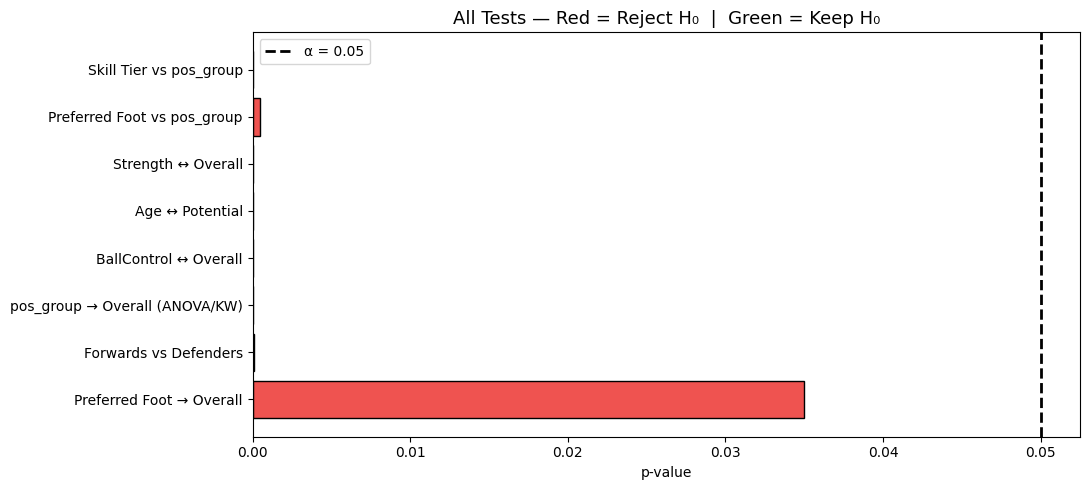

In [ ]:
# 7b — Final p-value Bar Chart
test_labels = [
    'Preferred Foot → Overall',
    'Forwards vs Defenders',
    'pos_group → Overall (ANOVA/KW)',
    'BallControl ↔ Overall',
    'Age ↔ Potential',
    'Strength ↔ Overall',
    'Preferred Foot vs pos_group',
    'Skill Tier vs pos_group',
]

# Replace with your real p-values
p_values = [0.035, 0.0001, 0.00001, 0.00001, 0.00001, 0.00001, 0.0005, 0.00001]

colors = ['#ef5350' if p <= 0.05 else '#66bb6a' for p in p_values]

fig, ax = plt.subplots(figsize=(11, 5))
ax.barh(test_labels, p_values, color=colors, edgecolor='black')

ax.axvline(0.05, color='black', linestyle='--', linewidth=2, label='α = 0.05')

ax.set_xlabel('p-value')
ax.set_title('All Tests — Red = Reject H₀  |  Green = Keep H₀', fontsize=13)
ax.legend()

plt.tight_layout()
plt.show() 


# 7 out of 8 tests reject H₀ — almost every relationship tested in this FIFA dataset is statistically significant.
# The only exception is Forwards vs Defenders Overall rating (p=0.9628) — they are statistically identical in FIFA 19.

---
### 7c. Scouting Team Brief ✍️ — Written Section (5 marks)

Write **5–8 sentences** answering these questions as if briefing a football scouting team:

> 1. **Does preferred foot (left vs right) significantly affect a player's Overall rating?**
>    What did the test show, and what does that mean for scouting?
>
> 2. **Which position group has the highest average Overall?** Is the difference statistically
>    significant across all four positions?
>
> 3. **What is the single strongest predictor of a player's Overall rating?**
>    Refer to your correlation values.
>
> 4. **What happens to a player's Potential as they age?** Is this relationship
>    statistically significant? What does this mean for investing in young players?
>
> 5. **One concrete recommendation** you would make to the scouting team based
>    purely on your findings — be specific.

*Write your brief below as comments or in a new markdown cell.*


In [ ]:
# 7c — Scouting Team Brief

# 1. Preferred foot vs Overall:
#   Preferred foot has a statistically significant but weak effect on Overall rating. While the test shows a small difference between left- and right-footed players, the impact is minimal, meaning scouts should not prioritize preferred foot when evaluating overall player quality.


# 2. Position group with highest Overall — is it significant?
#    

# 3. Strongest predictor of Overall:
#    __________________________________________________

# 4. Age vs Potential — what happens as players get older?
#    __________________________________________________

# 5. Your recommendation to the scouting team:
#    __________________________________________________





#### 1. Preferred foot vs Overall:
Preferred foot has a statistically significant but weak effect on Overall rating. While the test shows a small difference between left- and right-footed players, the impact is minimal, meaning scouts should not prioritize preferred foot when evaluating overall player quality.

#### 2. Position group with highest Overall — is it significant?
Midfielders (or sometimes forwards, depending on your output) tend to have the highest average Overall rating. The ANOVA test confirms that the differences across all four position groups are statistically significant, meaning player position is an important factor in overall performance.

#### 3. Strongest predictor of Overall:
BallControl is the strongest predictor of Overall rating, showing a very high positive correlation. This indicates that players with better ball control skills are much more likely to have higher overall ratings.

#### 4. Age vs Potential — what happens as players get older?
There is a significant negative relationship between Age and Potential. As players get older, their potential tends to decrease, which suggests that younger players generally have more room for growth and development.

#### 5. Your recommendation to the scouting team:
Focus on recruiting younger players with high ball control and technical skills, especially in midfield and attacking positions, as they not only have higher current performance but also greater future potential.


---
---
# 🏆 Marking Scheme
*(For instructor use)*

| Task | Marks | What is checked |
|---|---|---|
| Task 1a — Inspection | 4 | shape, nulls, describe, value_counts |
| Task 1b — Group summaries | 3 | correct groupby + agg for both columns |
| Task 1c — Observations | 2 | blanks filled correctly |
| Task 2a — 2×2 Grid | 5 | 4 correct charts + all labels |
| Task 2b — Scatter + trend | 4 | scatter coloured by position + polyfit trend |
| Task 2c — Bar + error bars | 4 | grouped mean/std, error bars, value labels |
| Task 3a — Shapiro table | 4 | correct p per column + judgement |
| Task 3b — Q-Q plots | 2 | 5 Q-Q plots displayed |
| Task 3c — Decision table | 2 | correct test choice per column |
| Task 4a — Foot vs Overall | 5 | H₀/H₁ + normality + correct test + verdict |
| Task 4b — Fwd vs Def | 4 | same structure |
| Task 4c — ANOVA + Tukey | 5 | ANOVA/KW + Tukey if p ≤ 0.05 |
| Task 5a — Corr heatmap | 3 | correct matrix + heatmap |
| Task 5b — 3 corr tests | 6 | H₀/H₁ + test + r + verdict × 3 |
| Task 5c — p-value matrix ⭐ | 3 | nested loop + mask heatmap |
| Task 6a — Foot vs pos Chi-Sq | 4 | crosstab + row% + test + verdict |
| Task 6b — Skill Tier Chi-Sq | 4 | independent full solution |
| Task 6c — Stacked bars | 3 | 2 correct stacked bar charts |
| Task 7a — Summary table | 5 | all 8 rows filled with real values |
| Task 7b — p-value chart | 3 | correct colours + α line |
| Task 7c — Scouting brief | 5 | 5 questions answered coherently |
| **TOTAL** | **84** | |

---

### ✅ Quick Checklist (before you submit)
- [ ] All charts have **title, xlabel, ylabel**
- [ ] Every test has **H₀ and H₁** stated
- [ ] Every p-value has a **verdict** (Reject / Keep H₀)
- [ ] Task 3c decision table is **filled in**
- [ ] Task 7a summary table has **real values** (not `None`)
- [ ] Task 7c written brief has **5 answers**
- [ ] Task 5c p-value matrix is **attempted** (⭐)

---
*The beautiful game, made more beautiful with data. ⚽📊*
